# Difference-in-Differences Analysis

Section 3 of the R draft: 16 early/late carbon-pricing adopters vs. 8 never-adopters.
See `src/did_analysis.py` module docstring for estimation-approach notes and the bugs
fixed relative to the R draft (`Selected_Country`, the `post`==`treat_post` collinearity).

In [ ]:
import sys
sys.path.append('..')

from src import config as cfg
from src.preprocessing import build_merged_data
from src import did_analysis as did

cfg.apply_theme_minimal()
merged_data = build_merged_data()
did_data = did.prepare_did_data(merged_data)
print(did_data.shape)

(553, 29)


## Setup checks

In [ ]:
countries, crosstab = did.did_setup_checks(did_data)
print(countries)
crosstab

['belgium', 'canada', 'finland', 'france', 'greece', 'ireland', 'italy', 'japan', 'korea, rep.', 'lithuania', 'new zealand', 'portugal', 'saudi arabia', 'sweden', 'turkiye', 'united states']


treated,0,1
adoption_year,,
False,0,280
True,273,0


## Parallel Trends Test (Pre-Treatment)

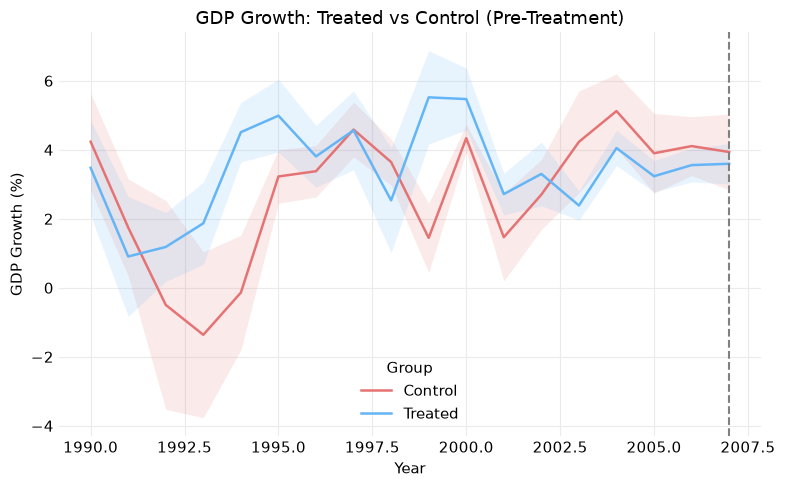

In [ ]:
stats = did.parallel_trends_stats(did_data, 'gdp_growth')
fig, ax = did.plot_parallel_trends(stats, 'GDP Growth: Treated vs Control (Pre-Treatment)', 'GDP Growth (%)', save_path=cfg.FIGURES_DIR / 'parallel_trends_gdp_growth.png')

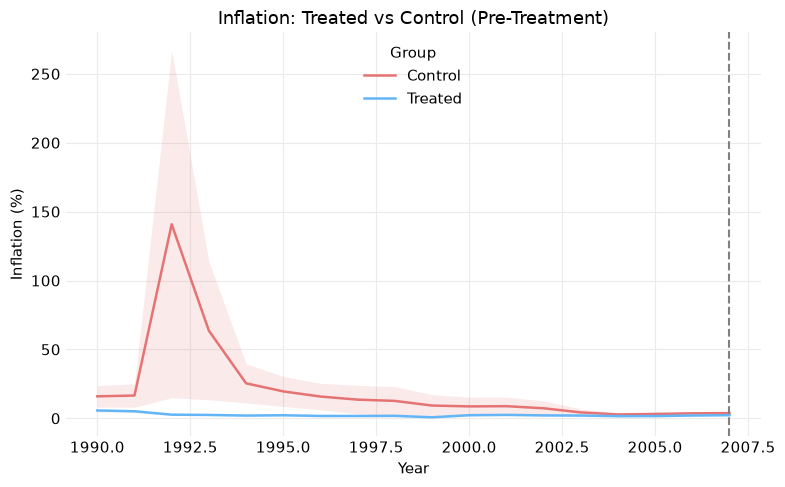

In [ ]:
stats = did.parallel_trends_stats(did_data, 'inflation')
fig, ax = did.plot_parallel_trends(stats, 'Inflation: Treated vs Control (Pre-Treatment)', 'Inflation (%)', save_path=cfg.FIGURES_DIR / 'parallel_trends_inflation.png')

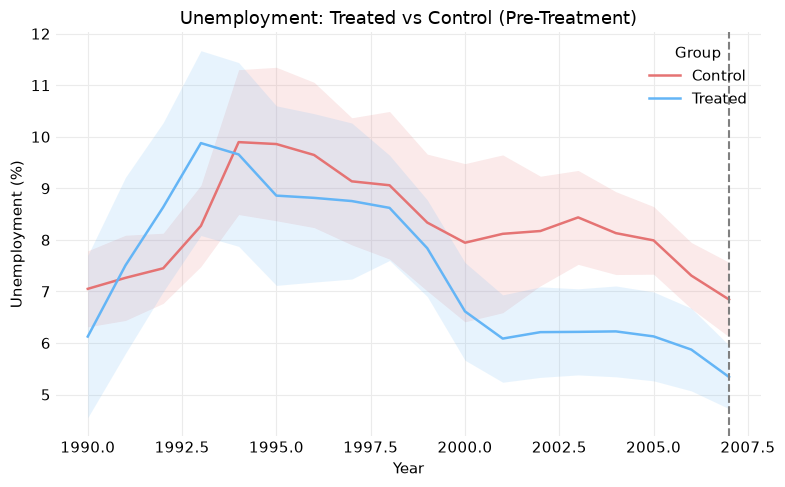

In [ ]:
stats = did.parallel_trends_stats(did_data, 'unemployment')
fig, ax = did.plot_parallel_trends(stats, 'Unemployment: Treated vs Control (Pre-Treatment)', 'Unemployment (%)', save_path=cfg.FIGURES_DIR / 'parallel_trends_unemployment.png')

## Difference-in-Differences Estimation (GDP growth / Inflation / Unemployment)

In [ ]:
main_models = did.run_main_did_models(did_data)
for outcome, res in main_models.items():
    table = did.coef_table(res, did.MAIN_REGRESSORS)
    table.to_csv(cfg.TABLES_DIR / f'did_main_model_{outcome}.csv')
    print(f'--- {outcome} ---')
    print(table)
    print()

--- gdp_growth ---
                                 coef       std_err   p_value        ci_low  \
post                     5.412488e-01  1.118456e+00  0.628439 -1.650884e+00   
treat_post                        NaN           NaN       NaN           NaN   
trade_openness           2.973460e+00  2.527489e+00  0.239416 -1.980328e+00   
renewable_energy_pct     1.832233e-02  8.033835e-02  0.819596 -1.391379e-01   
manufacturing_growth    -2.483136e-12  2.402122e-12  0.301264 -7.191209e-12   
ores_metals_exports_pct -4.554873e-02  4.887765e-01  0.925753 -1.003533e+00   
population               6.103857e-08  5.229125e-08  0.243097 -4.145041e-08   

                              ci_high  
post                     2.733382e+00  
treat_post                        NaN  
trade_openness           7.927247e+00  
renewable_energy_pct     1.757826e-01  
manufacturing_growth     2.224937e-12  
ores_metals_exports_pct  9.124356e-01  
population               1.635275e-07  

--- inflation ---
         

## Event Study: Dynamic Effect of Carbon Pricing on GDP Growth

,coef,std_err,p_value,ci_low,ci_high
event_-5,0.892149,1.635212,0.585351,-2.312809,4.097106
event_-4,0.582963,1.578602,0.711911,-2.511041,3.676967
event_-3,0.796856,1.194537,0.504719,-1.544394,3.138106
event_-2,-0.212637,0.760585,0.779807,-1.703356,1.278082
event_0,1.386336,1.083524,0.200732,-0.737332,3.510003
event_1,1.386147,1.383899,0.316525,-1.326246,4.098539
event_2,0.910478,1.188504,0.443635,-1.418948,3.239904
event_3,2.079608,1.669680,0.212943,-1.192904,5.352119
event_4,2.955075,2.297944,0.198455,-1.548812,7.458961
event_5,3.050422,2.051692,0.137072,-0.970821,7.071666


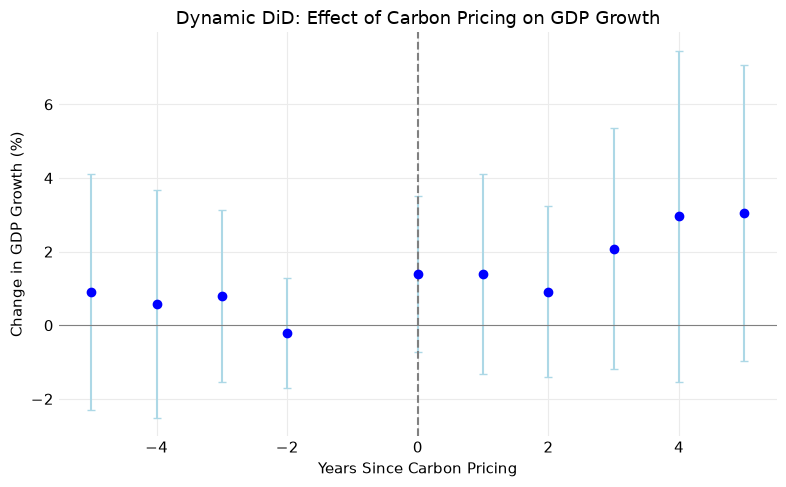

In [ ]:
res_event, dummy_cols = did.run_event_study(did_data, 'gdp_growth')
event_table = did.coef_table(res_event, dummy_cols)
event_table.to_csv(cfg.TABLES_DIR / 'did_event_study_gdp_growth.csv')
fig, ax = did.plot_event_study(res_event, dummy_cols, 'Dynamic DiD: Effect of Carbon Pricing on GDP Growth', 'Change in GDP Growth (%)', save_path=cfg.FIGURES_DIR / 'event_study_gdp_growth.png')
event_table

(The R draft's second event study, `i(Year_rel, treated, ref=-1)`, collapses to the same
specification on this treated-only subsample -- see `did_analysis.build_event_study_data` docstring.)

## Early vs. Late Adopters Comparison

In [ ]:
early_late_models = did.run_early_late_models(did_data)
for outcome, res in early_late_models.items():
    table = did.coef_table(res, did.EARLY_LATE_REGRESSORS)
    table.to_csv(cfg.TABLES_DIR / f'did_early_late_{outcome}.csv')
    print(f'--- {outcome} ---')
    print(table)
    print()

--- gdp_growth ---
                                 coef       std_err   p_value        ci_low  \
early_post               3.681022e+00  1.597510e+00  0.021210  5.499595e-01   
late_post               -1.098113e+00  7.258170e-01  0.130296 -2.520688e+00   
trade_openness           5.667665e+00  2.367036e+00  0.016647  1.028360e+00   
renewable_energy_pct     5.376114e-03  6.926984e-02  0.938137 -1.303903e-01   
manufacturing_growth    -3.742866e-12  3.076554e-12  0.223765 -9.772802e-12   
ores_metals_exports_pct  3.384065e-01  4.679260e-01  0.469554 -5.787116e-01   
population               8.926781e-08  6.601110e-08  0.176275 -4.011157e-08   

                              ci_high  
early_post               6.812084e+00  
late_post                3.244621e-01  
trade_openness           1.030697e+01  
renewable_energy_pct     1.411425e-01  
manufacturing_growth     2.287069e-12  
ores_metals_exports_pct  1.255525e+00  
population               2.186472e-07  

--- inflation ---
         

## Missing Values by Country

In [ ]:
na_by_country = did.na_counts_by_country(did_data)
na_by_country.to_csv(cfg.TABLES_DIR / 'did_na_counts_by_country.csv')
na_by_country

,gdp_growth,inflation,unemployment,trade_openness,renewable_energy_pct,manufacturing_growth,ores_metals_exports_pct,population
country,,,,,,,,
belgium,0,0,0,9,2,6,9,0
canada,1,1,1,1,3,9,1,1
finland,1,1,1,1,3,1,1,1
france,1,1,1,1,3,1,1,1
greece,0,0,0,0,2,6,0,0
ireland,1,1,1,1,3,7,1,1
italy,0,0,0,0,2,1,0,0
japan,1,1,1,1,3,7,1,1
"korea, rep.",1,1,1,1,3,1,2,1


## Placebo Test (Fake Policy Year 2000)

In [ ]:
placebo_res = did.run_placebo_test(did_data)
placebo_table = did.coef_table(placebo_res, did.PLACEBO_REGRESSORS)
placebo_table.to_csv(cfg.TABLES_DIR / 'did_placebo_test.csv')
placebo_table

,coef,std_err,p_value,ci_low,ci_high
fake_post,-1.554066e+00,6.418165e-01,0.015463,-2.812003e+00,-2.961288e-01
fake_treat_post,7.595487e-02,7.300767e-01,0.917140,-1.354969e+00,1.506879e+00
trade_openness,2.515530e+00,2.443121e+00,0.303180,-2.272900e+00,7.303960e+00
renewable_energy_pct,-2.443904e-03,6.422595e-02,0.969646,-1.283244e-01,1.234366e-01
ores_metals_exports_pct,-2.365764e-01,3.576442e-01,0.508301,-9.375461e-01,4.643933e-01
population,1.280854e-08,1.187887e-08,0.280917,-1.047362e-08,3.609070e-08


## Sensitivity Test (Narrower EU Control Group)

Fixes two issues in the R draft: `Selected_Country` doesn't exist (uses `Country`),
and the EU comparators aren't in the already-16-country-restricted `merged_data` by this
point in the R script -- rebuilt from the full, unrestricted dataset instead
(see `did_analysis.run_sensitivity_test` docstring).

In [ ]:
sensitivity_res = did.run_sensitivity_test(merged_data)
sensitivity_table = did.coef_table(sensitivity_res, did.MAIN_REGRESSORS)
sensitivity_table.to_csv(cfg.TABLES_DIR / 'did_sensitivity_test.csv')
sensitivity_table

,coef,std_err,p_value,ci_low,ci_high
post,1.383519e+00,3.275516e-01,2.401965e-05,7.415295e-01,2.025508e+00
treat_post,NaN,NaN,NaN,NaN,NaN
trade_openness,1.570527e+00,8.272339e-01,5.762650e-02,-5.082151e-02,3.191876e+00
renewable_energy_pct,3.089488e-02,2.743172e-02,2.600612e-01,-2.287030e-02,8.466005e-02
manufacturing_growth,2.462233e-01,1.903643e-02,2.881533e-38,2.089126e-01,2.835341e-01
ores_metals_exports_pct,1.791700e-01,8.432475e-02,3.360649e-02,1.389654e-02,3.444435e-01
population,-2.011719e-07,4.210766e-08,1.774340e-06,-2.837014e-07,-1.186424e-07
